<a href="https://www.kaggle.com/code/lalit7881/popular-movies-dataset-eda-100?scriptVersionId=332448685" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/okayyysidd/popular-movies-dataset/popular_shows_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/okayyysidd/popular-movies-dataset/popular_shows_dataset.csv")

In [3]:
df.head()

,title,year,revenue,imdb_id,tmdb_id,trakt_id
0,Hoppers,2026,29000000,tt26443616,1327819,1085761
1,Reminders of Him,2026,18000000,tt33714084,1367642,1116720
2,undertone,2026,9300000,tt35892608,1480387,1213506
3,Scream 7,2026,8400000,tt27047903,1159559,934134
4,GOAT,2026,4700000,tt27613895,1297842,1057839


In [4]:
df.tail()

,title,year,revenue,imdb_id,tmdb_id,trakt_id
995,The Bride!,2026,2100000,tt30851137,1159831,934595
996,Kiki's Delivery Service,1989,1700000,tt0097814,16859,10314
997,"""Wuthering Heights""",2026,1700000,tt32897959,1316092,1077273
998,Teenage Mutant Ninja Turtles II: The Secret of...,1991,1500000,tt0103060,1497,991
999,Crime 101,2026,1100000,tt32430579,1171145,944042


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     1000 non-null   object
 1   year      1000 non-null   int64 
 2   revenue   1000 non-null   int64 
 3   imdb_id   1000 non-null   object
 4   tmdb_id   1000 non-null   int64 
 5   trakt_id  1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


In [6]:
df.describe()

,year,revenue,tmdb_id,trakt_id
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,2018.800000,7.750000e+06,1.029867e+06,8.375175e+05
std,14.414152,8.705877e+06,5.195836e+05,4.246083e+05
min,1989.000000,1.100000e+06,1.497000e+03,9.910000e+02
25%,2026.000000,1.700000e+06,1.159559e+06,9.341340e+05
50%,2026.000000,3.400000e+06,1.234494e+06,1.000940e+06
75%,2026.000000,9.300000e+06,1.327819e+06,1.085761e+06
max,2026.000000,2.900000e+07,1.480387e+06,1.213506e+06


In [7]:
df.isnull()

,title,year,revenue,imdb_id,tmdb_id,trakt_id
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
995,False,False,False,False,False,False
996,False,False,False,False,False,False
997,False,False,False,False,False,False
998,False,False,False,False,False,False


In [8]:
df.isnull().sum()

title       0
year        0
revenue     0
imdb_id     0
tmdb_id     0
trakt_id    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(990)

In [10]:
df.dtypes

title       object
year         int64
revenue      int64
imdb_id     object
tmdb_id      int64
trakt_id     int64
dtype: object

In [11]:
df.shape

(1000, 6)

In [12]:
df.columns

Index(['title', 'year', 'revenue', 'imdb_id', 'tmdb_id', 'trakt_id'], dtype='object')

In [13]:
df.nunique()

title       10
year         3
revenue      9
imdb_id     10
tmdb_id     10
trakt_id    10
dtype: int64

## EDA

Dataset Shape
(1000, 6)
First Five Rows
              title  year   revenue     imdb_id  tmdb_id  trakt_id
0           Hoppers  2026  29000000  tt26443616  1327819   1085761
1  Reminders of Him  2026  18000000  tt33714084  1367642   1116720
2         undertone  2026   9300000  tt35892608  1480387   1213506
3          Scream 7  2026   8400000  tt27047903  1159559    934134
4              GOAT  2026   4700000  tt27613895  1297842   1057839
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     1000 non-null   object
 1   year      1000 non-null   int64 
 2   revenue   1000 non-null   int64 
 3   imdb_id   1000 non-null   object
 4   tmdb_id   1000 non-null   int64 
 5   trakt_id  1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB
None
Missing Values
title       0
year        0
revenue     0
imdb_id     0
tm

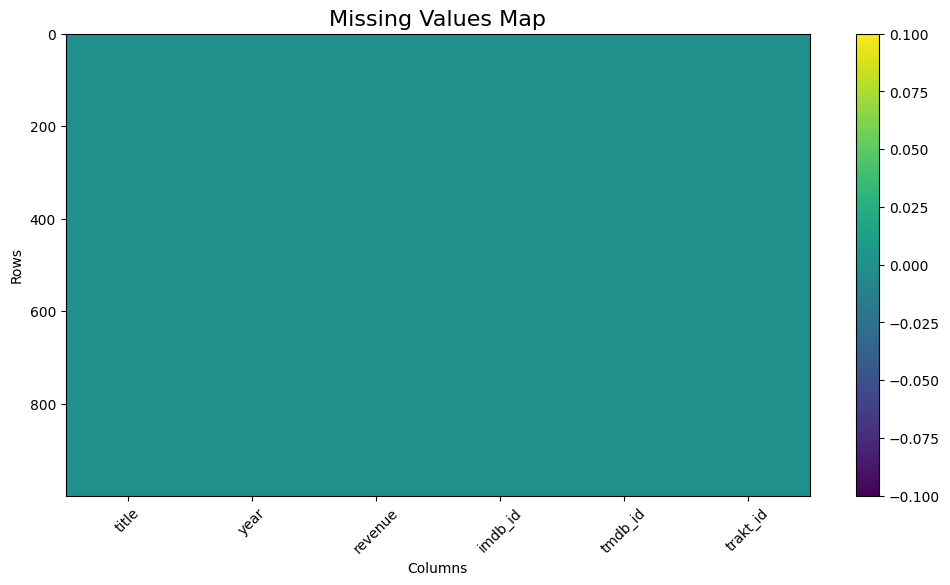

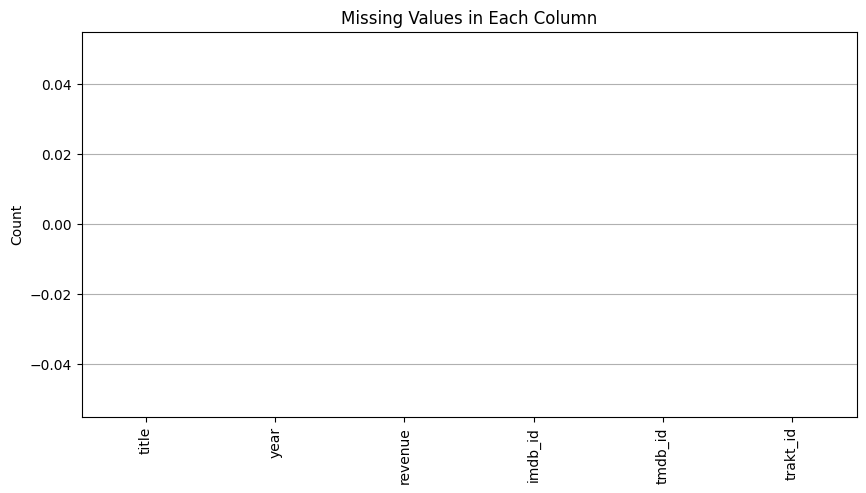

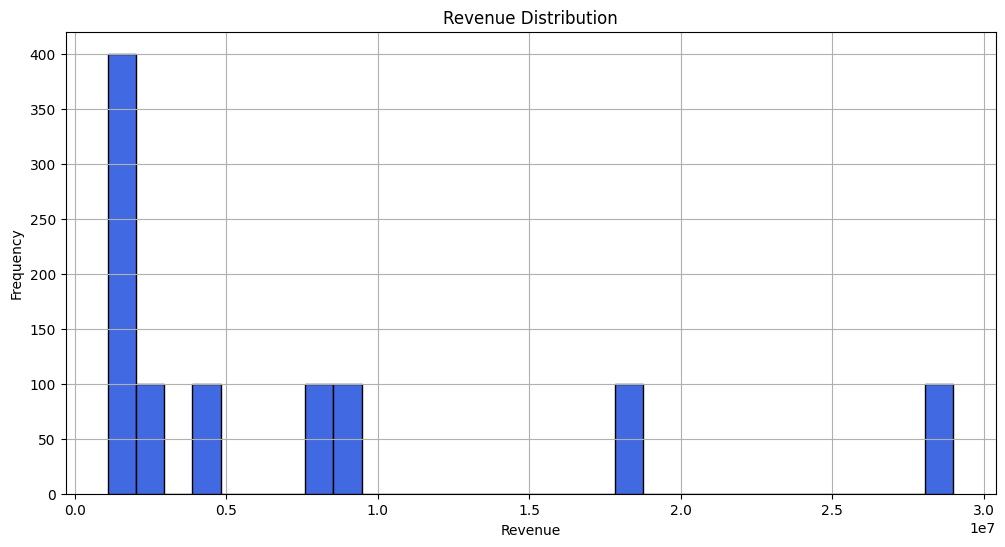

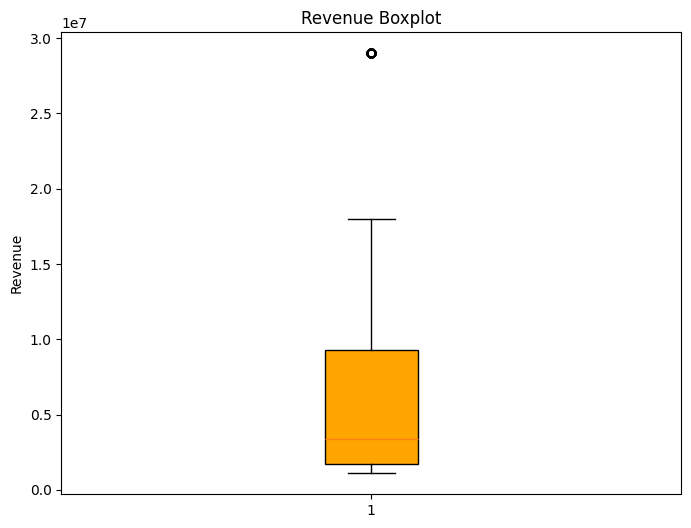

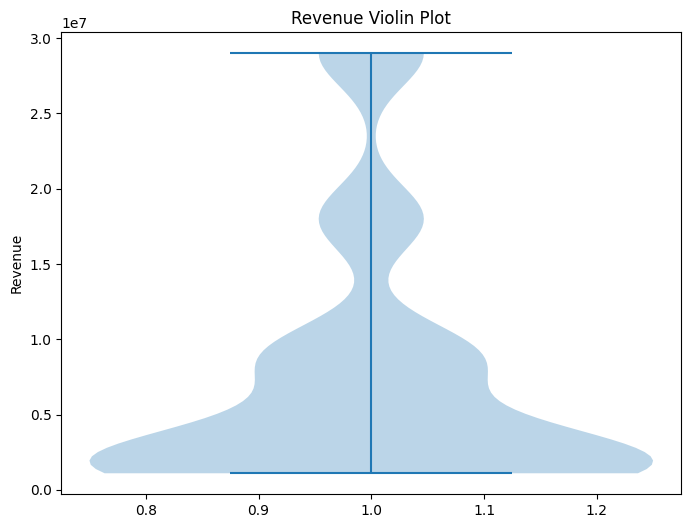

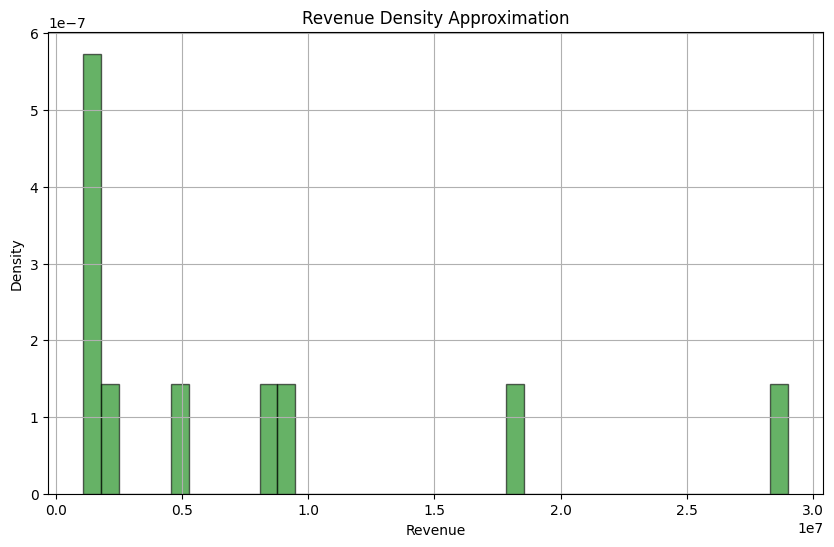

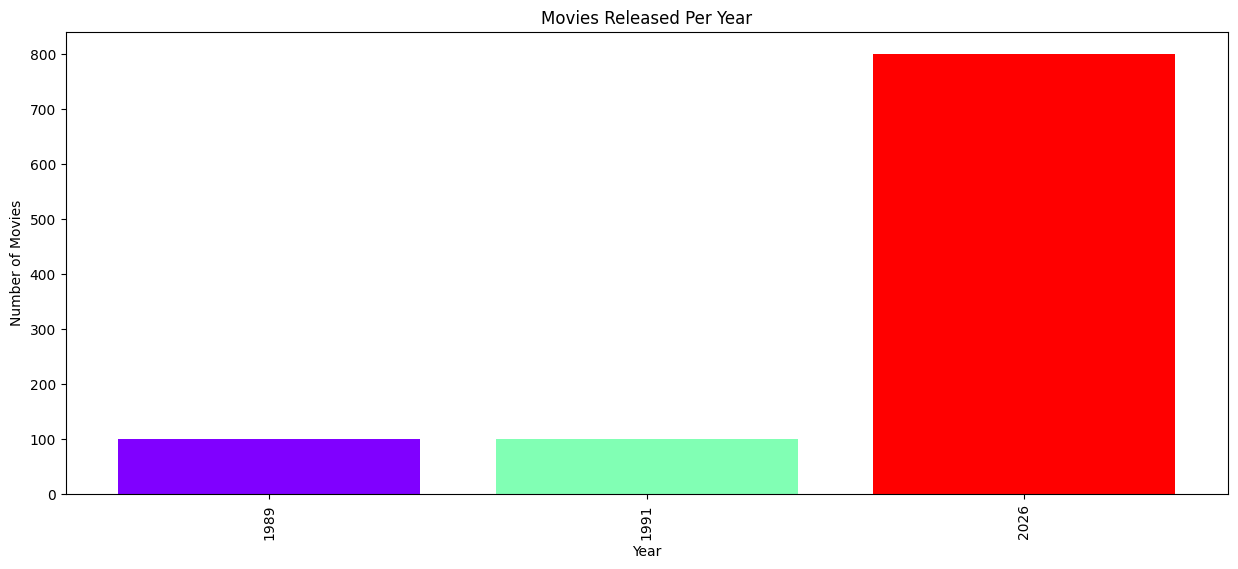

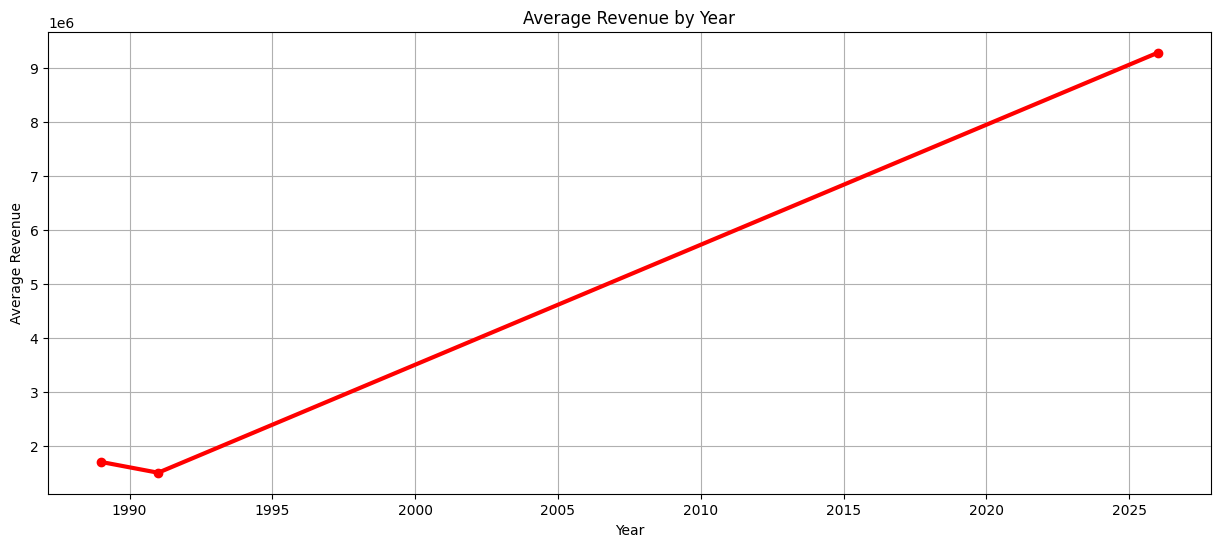

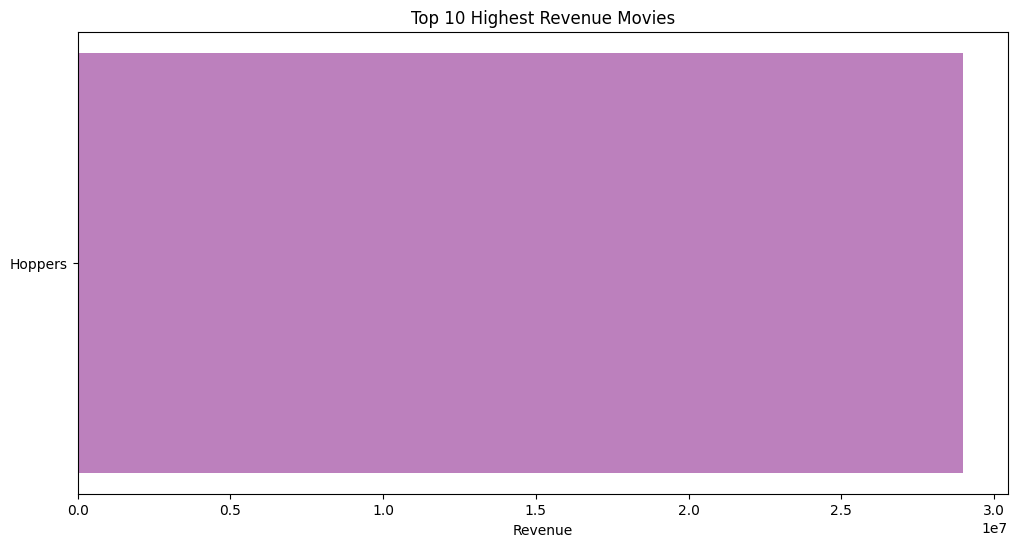

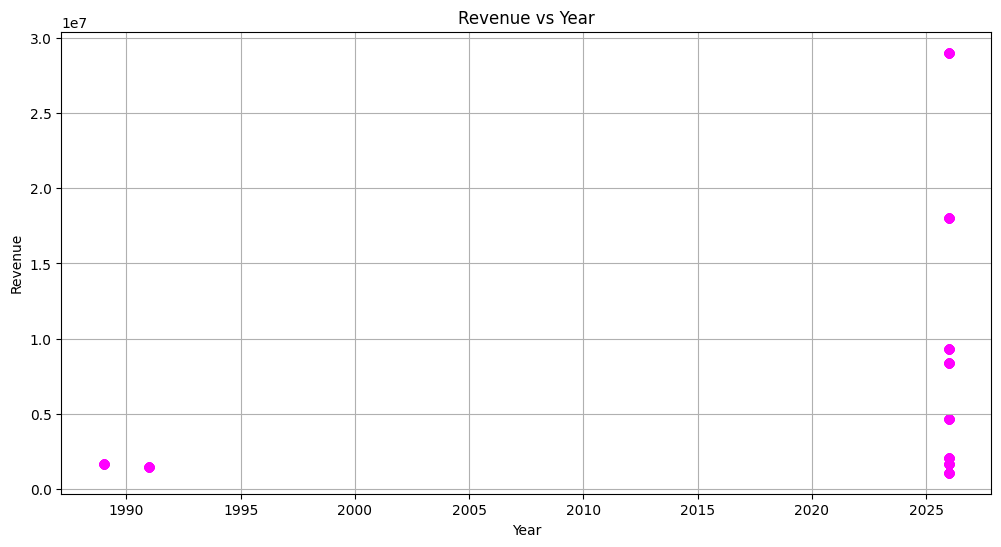

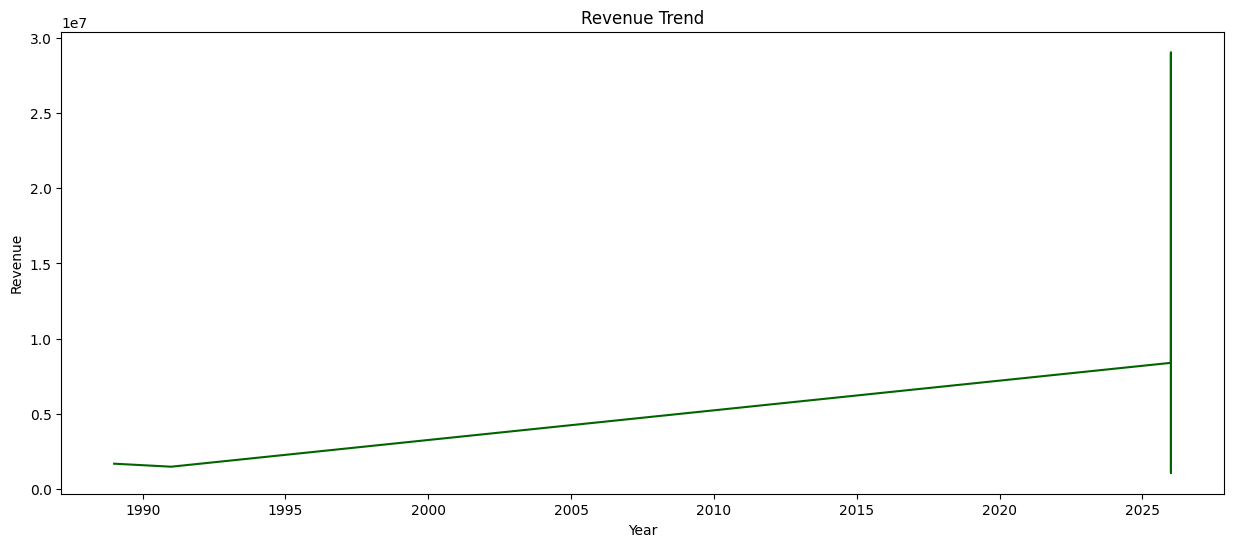

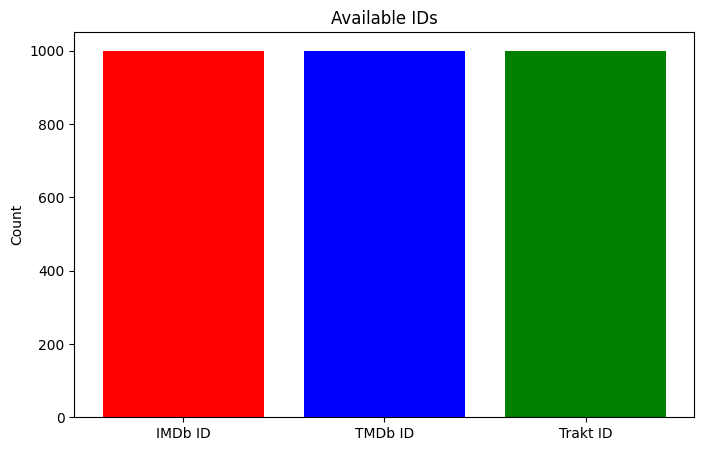

EDA Completed Successfully


In [14]:
import plotly.express as px

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Load Dataset
# -------------------------------
# df = pd.read_csv("movies.csv")

print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print("First Five Rows")
print(df.head())

print("="*60)
print("Dataset Information")
print(df.info())

print("="*60)
print("Missing Values")
print(df.isnull().sum())

print("="*60)
print("Descriptive Statistics")
print(df.describe(include='all'))

# ==========================================
# Convert revenue and year to numeric
# ==========================================

df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# ==========================================
# Missing Values Heatmap
# ==========================================

plt.figure(figsize=(12,6))
plt.imshow(df.isnull(), aspect='auto', cmap='viridis')
plt.title("Missing Values Map", fontsize=16)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.show()

# ==========================================
# Missing Values Count
# ==========================================

plt.figure(figsize=(10,5))

df.isnull().sum().plot(
    kind='bar',
    color=['red','blue','green','orange','purple','brown']
)

plt.title("Missing Values in Each Column")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

# ==========================================
# Revenue Distribution Histogram
# ==========================================

plt.figure(figsize=(12,6))

plt.hist(
    df['revenue'].dropna(),
    bins=30,
    color='royalblue',
    edgecolor='black'
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# ==========================================
# Revenue Boxplot
# ==========================================

plt.figure(figsize=(8,6))

plt.boxplot(
    df['revenue'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='orange')
)

plt.title("Revenue Boxplot")
plt.ylabel("Revenue")
plt.show()

# ==========================================
# Revenue Violin Plot
# ==========================================

plt.figure(figsize=(8,6))

plt.violinplot(df['revenue'].dropna())

plt.title("Revenue Violin Plot")
plt.ylabel("Revenue")
plt.show()

# ==========================================
# Revenue Density Curve (Histogram Approximation)
# ==========================================

plt.figure(figsize=(10,6))

plt.hist(
    df['revenue'].dropna(),
    bins=40,
    density=True,
    alpha=0.6,
    color='green',
    edgecolor='black'
)

plt.title("Revenue Density Approximation")
plt.xlabel("Revenue")
plt.ylabel("Density")
plt.grid(True)
plt.show()

# ==========================================
# Movies Released Every Year
# ==========================================

year_count = df['year'].value_counts().sort_index()

plt.figure(figsize=(15,6))

plt.bar(
    year_count.index.astype(str),
    year_count.values,
    color=plt.cm.rainbow(np.linspace(0,1,len(year_count)))
)

plt.xticks(rotation=90)

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

# ==========================================
# Revenue by Year
# ==========================================

rev_year = df.groupby('year')['revenue'].mean()

plt.figure(figsize=(15,6))

plt.plot(
    rev_year.index,
    rev_year.values,
    color='red',
    marker='o',
    linewidth=3
)

plt.title("Average Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Average Revenue")
plt.grid(True)
plt.show()

# ==========================================
# Top 10 Highest Revenue Movies
# ==========================================

top10 = df.sort_values(
    by='revenue',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10['title'],
    top10['revenue'],
    color=plt.cm.Set3(np.arange(len(top10)))
)

plt.title("Top 10 Highest Revenue Movies")
plt.xlabel("Revenue")
plt.gca().invert_yaxis()
plt.show()

# ==========================================
# Revenue Scatter Plot
# ==========================================

plt.figure(figsize=(12,6))

plt.scatter(
    df['year'],
    df['revenue'],
    color='magenta',
    alpha=0.7
)

plt.title("Revenue vs Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# ==========================================
# Revenue Line Chart (Sorted)
# ==========================================

sorted_df = df.sort_values('year')

plt.figure(figsize=(15,6))

plt.plot(
    sorted_df['year'],
    sorted_df['revenue'],
    color='darkgreen'
)

plt.title("Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

# ==========================================
# Correlation Heatmap
# ==========================================

corr = df[['year','revenue']].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu',
    title='Correlation Heatmap'
)

fig.show()

# ==========================================
# Revenue Pie Chart (Top 10 Movies)
# ==========================================

fig = px.pie(
    top10,
    names='title',
    values='revenue',
    color_discrete_sequence=px.colors.qualitative.Bold,
    title='Revenue Share of Top 10 Movies'
)

fig.show()

# ==========================================
# Revenue Treemap
# ==========================================

fig = px.treemap(
    top10,
    path=['title'],
    values='revenue',
    color='revenue',
    color_continuous_scale='Turbo',
    title='Revenue Treemap'
)

fig.show()

# ==========================================
# Revenue Box Plot by Decade
# ==========================================

df['Decade'] = (df['year']//10)*10

fig = px.box(
    df,
    x='Decade',
    y='revenue',
    color='Decade',
    title='Revenue Distribution by Decade'
)

fig.show()

# ==========================================
# ID Availability
# ==========================================

id_counts = {
    'IMDb ID':df['imdb_id'].notna().sum(),
    'TMDb ID':df['tmdb_id'].notna().sum(),
    'Trakt ID':df['trakt_id'].notna().sum()
}

plt.figure(figsize=(8,5))

plt.bar(
    id_counts.keys(),
    id_counts.values(),
    color=['red','blue','green']
)

plt.title("Available IDs")
plt.ylabel("Count")
plt.show()

# ==========================================
# Revenue Bubble Chart
# ==========================================

fig = px.scatter(
    df,
    x='year',
    y='revenue',
    size='revenue',
    color='year',
    hover_name='title',
    color_continuous_scale='Rainbow',
    title='Revenue Bubble Chart'
)

fig.show()

# ==========================================
# Revenue Histogram (Interactive)
# ==========================================

fig = px.histogram(
    df,
    x='revenue',
    nbins=40,
    color_discrete_sequence=['darkorange'],
    title='Interactive Revenue Histogram'
)

fig.show()

print("="*70)
print("EDA Completed Successfully")
print("="*70)

## feature engineering


Target Distribution
Target
1    5
0    5
Name: count, dtype: int64

Logistic Regression

Accuracy : 0.5
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 1.0

Confusion Matrix
[[1 0]
 [1 0]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Decision Tree

Accuracy : 0.5
Precision : 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.5

Confusion Matrix
[[1 0]
 [1 0]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50    

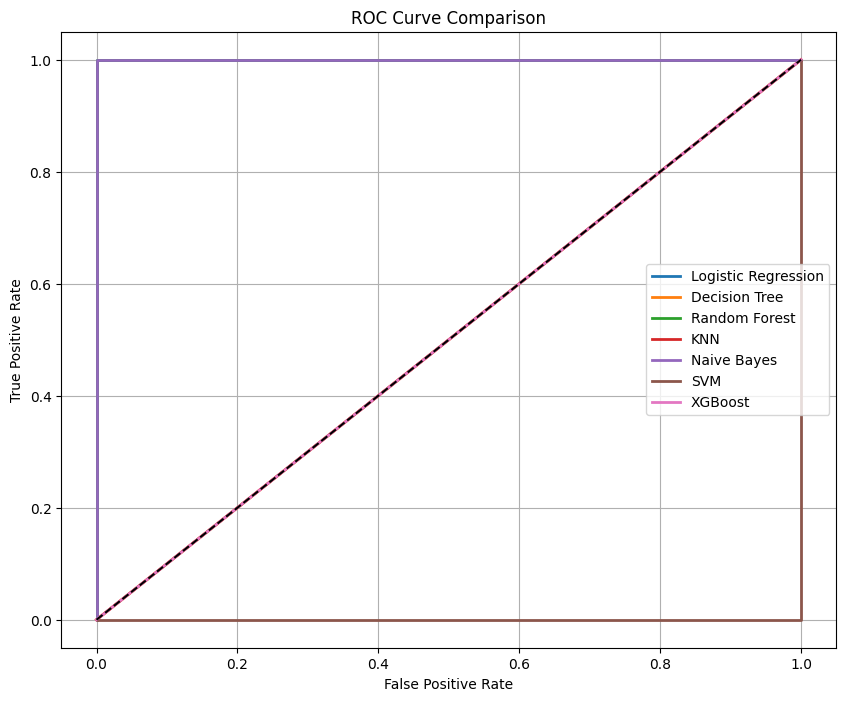



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
4          Naive Bayes       1.0        1.0     1.0       1.0      1.0
1        Decision Tree       0.5        0.0     0.0       0.0      0.5
0  Logistic Regression       0.5        0.0     0.0       0.0      1.0
2        Random Forest       0.5        0.0     0.0       0.0      1.0
3                  KNN       0.5        0.0     0.0       0.0      0.5
5                  SVM       0.5        0.0     0.0       0.0      0.0
6              XGBoost       0.5        0.0     0.0       0.0      0.5


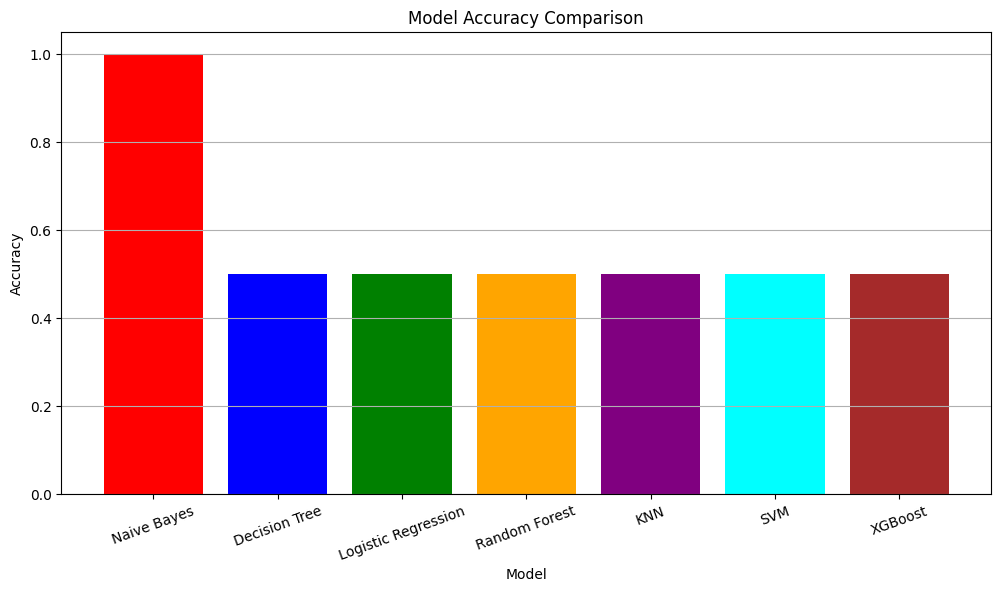


Best Model
Model        Naive Bayes
Accuracy             1.0
Precision            1.0
Recall               1.0
F1 Score             1.0
ROC AUC              1.0
Name: 4, dtype: object


In [15]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert numeric columns
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Drop rows where revenue is missing
df = df.dropna(subset=['revenue'])

# Fill missing values
df['title'] = df['title'].fillna("Unknown")
df['year'] = df['year'].fillna(df['year'].median())

# Fill ID columns
for col in ['imdb_id', 'tmdb_id', 'trakt_id']:
    df[col] = df[col].fillna("missing")

# ============================================================
# CREATE TARGET
# ============================================================

median_revenue = df['revenue'].median()

df['Target'] = (df['revenue'] >= median_revenue).astype(int)

print("\nTarget Distribution")
print(df['Target'].value_counts())

# ============================================================
# FEATURES
# ============================================================

X = df[['title','year','imdb_id','tmdb_id','trakt_id']].copy()

y = df['Target']

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# LABEL ENCODING (NO DATA LEAKAGE)
# ============================================================

from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    'title',
    'imdb_id',
    'tmdb_id',
    'trakt_id'
]

for col in categorical_columns:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    mapping = dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )

    X_test[col] = X_test[col].astype(str).map(mapping)

    X_test[col] = X_test[col].fillna(-1)

    X_test[col] = X_test[col].astype(int)

    encoders[col] = le

# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

# XGBoost (Optional)

try:

    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

except:
    print("XGBoost not installed")

# ============================================================
# EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    print("\n"+"="*70)
    print(name)
    print("="*70)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    roc = roc_auc_score(y_test, probability)

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1,

        roc

    ])

    print("\nAccuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("ROC AUC :", roc)

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test,prediction))

    print("\nClassification Report")

    print(classification_report(y_test,prediction))

    fpr, tpr, threshold = roc_curve(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=name
    )

# ============================================================
# ROC CURVE
# ============================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ]

)

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results)

# ============================================================
# BAR CHART
# ============================================================

plt.figure(figsize=(12,6))

plt.bar(
    results["Model"],
    results["Accuracy"],
    color=[
        'red',
        'blue',
        'green',
        'orange',
        'purple',
        'cyan',
        'brown'
    ][:len(results)]
)

plt.ylabel("Accuracy")

plt.xlabel("Model")

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results.iloc[0]

print("\nBest Model")

print(best_model)

## Thank you..pls upvote!!!!!!!!!!!!